In [1]:
import pandas as pd

data = pd.read_csv('data_clean.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43746 entries, 0 to 43745
Data columns (total 80 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   year                                       43746 non-null  int64  
 1   population                                 43746 non-null  int64  
 2   gdp                                        43746 non-null  float64
 3   cement_co2                                 43746 non-null  float64
 4   cement_co2_per_capita                      43746 non-null  float64
 5   co2                                        43746 non-null  float64
 6   co2_growth_abs                             43746 non-null  float64
 7   co2_growth_prct                            43746 non-null  float64
 8   co2_including_luc                          43746 non-null  float64
 9   co2_including_luc_growth_abs               43746 non-null  float64
 10  co2_including_luc_grow

In [2]:
# filter only on country
grouped_data = data[data['Description'] == 'Country'].groupby('Name').mean(numeric_only=True).drop(columns=['year'])
grouped_data


,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
Name,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1.074678e+07,3.962243e+10,0.014672,0.001023,217.576906,0.074434,13.418594,49.908846,0.765903,11.559825,...,0.004751,0.127425,0.000068,0.000059,0.000431,0.0,17.033126,3.389977,0.401786,0.767840
Albania,1.562149e+06,9.437066e+09,0.158491,0.064352,160.487772,0.021782,19.362402,29.352684,2.215374,-11.051863,...,0.000362,0.030057,0.000000,0.000000,0.000000,0.0,5.262144,2.556615,0.129026,6.163871
Algeria,1.317316e+07,1.075402e+11,1.485837,0.056006,113.177667,1.029072,16.647756,64.451568,1.784368,6.364045,...,0.005805,0.154529,0.000914,0.000345,0.001305,0.0,62.854931,55.638529,0.491549,1.248472
Andorra,2.181065e+04,1.229519e+09,0.000000,0.000000,724.339049,1.211111,6.468269,9.869925,2.285614,3.293320,...,0.000000,0.000299,0.000000,0.000000,0.000000,0.0,0.157466,0.121247,0.000000,0.000000
Angola,7.587399e+06,3.315717e+10,0.180753,0.018084,258.526561,0.166577,13.005495,81.972277,1.213836,3.012833,...,0.000536,0.197328,0.000500,0.000621,0.001276,0.0,56.097494,14.101603,-0.211957,-0.006706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,9.398760e+06,1.084045e+11,0.866810,0.049460,51.378808,0.574816,54.178797,85.701761,0.878732,5.379618,...,0.000178,0.784649,0.001787,0.001868,0.003759,0.0,126.560621,77.842305,-8.169890,-5.764884
Vietnam,3.411535e+07,1.418942e+11,4.341622,0.053261,62.569606,1.923913,11.404478,102.230689,2.742390,8.811685,...,0.005559,0.769793,0.001149,0.001925,0.003121,0.0,123.756724,45.276052,-5.956002,-2.345579
Yemen,8.521856e+06,3.616862e+10,0.163005,0.022318,172.055154,0.047446,47.843172,44.816597,1.749623,95.447175,...,0.000759,0.025603,0.000092,0.000000,0.000132,0.0,10.689609,7.577989,-0.159716,0.070554


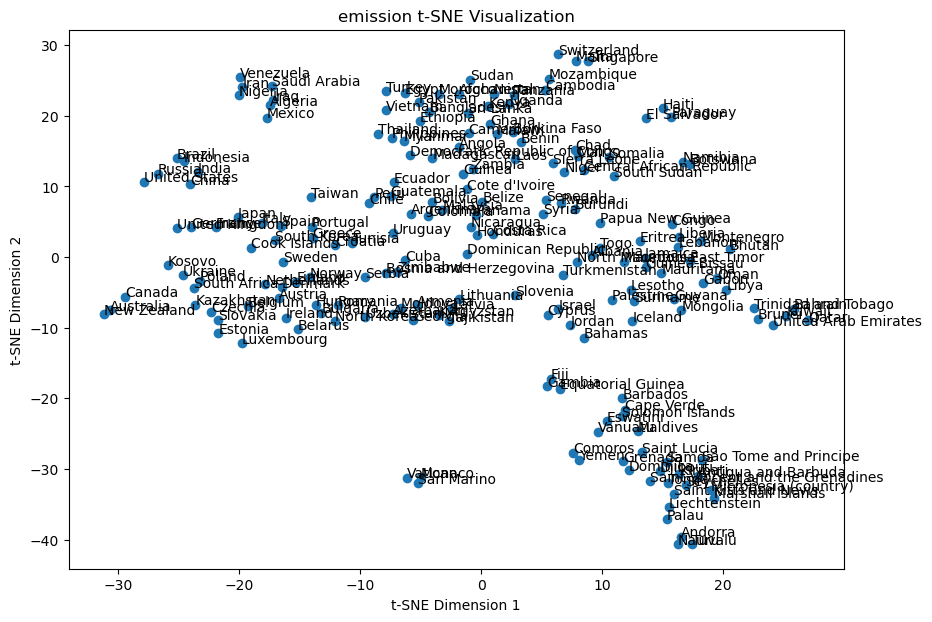

In [3]:
# t-sne analysis and visualization
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt 

features = grouped_data.columns.tolist()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(grouped_data)
tsne = TSNE(n_components=2, random_state=42, perplexity=11)
tsne_results = tsne.fit_transform(scaled_data)
plt.figure(figsize=(10, 7))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
for i, name in enumerate(grouped_data.index):
    plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]))
plt.title('emission t-SNE Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()




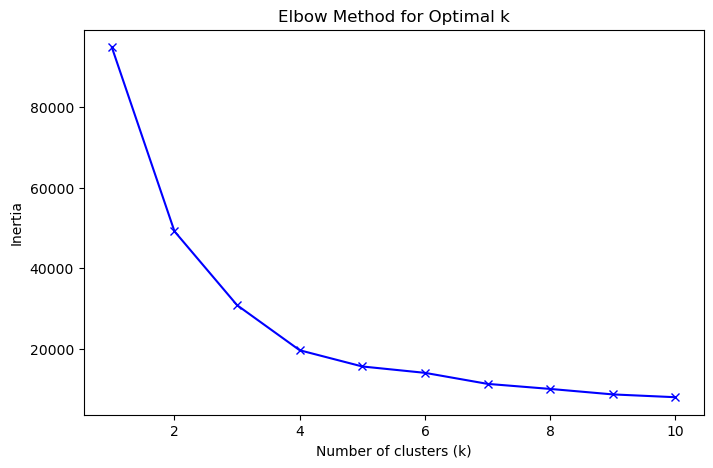

In [4]:
# kmeans clustering elbow method

from sklearn.cluster import KMeans
import numpy as np

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tsne_results)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()



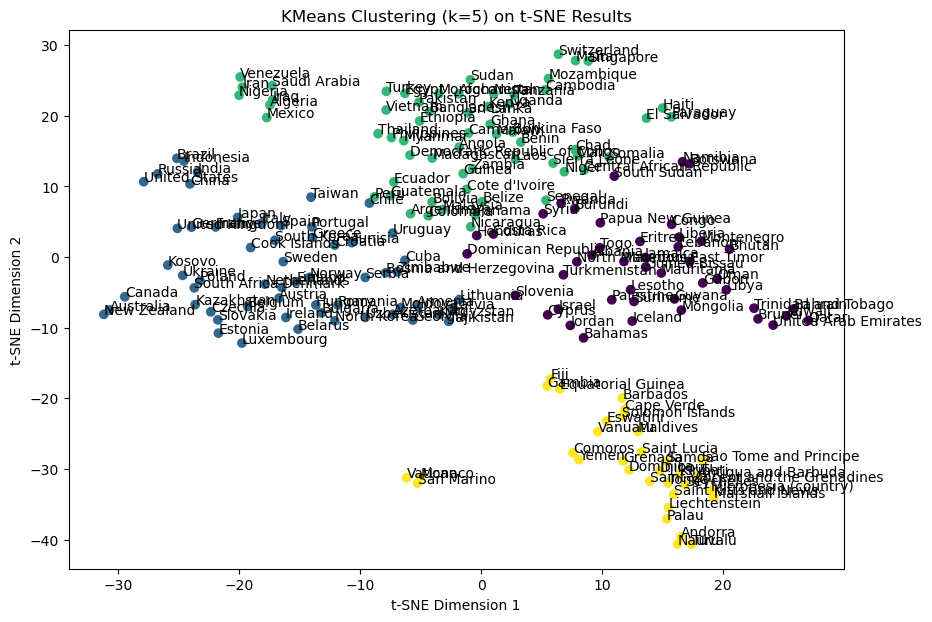

In [ ]:
# kmeans clustering with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
grouped_data['Cluster'] = kmeans.fit_predict(tsne_results)
plt.figure(figsize=(10, 7))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=grouped_data['Cluster'], cmap='viridis')
for i, name in enumerate(grouped_data.index):
    plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]))
plt.title('KMeans Clustering (k=5) on t-SNE Results')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [7]:
import pandas as pd

# Your grouped_data already has 'Cluster' column from kmeans
# Generate cluster characteristics table

# Get list of all numeric columns in grouped_data (excluding 'Cluster')
numeric_cols = grouped_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Cluster' in numeric_cols:
    numeric_cols.remove('Cluster')

print("Available columns:", numeric_cols[:10])  # Check what columns you have

# Select key metrics for the table
key_metrics = [
    'population',
    'gdp',
    'co2',
    'co2_per_capita',
    'methane',
    'nitrous_oxide',
    'total_ghg',
    'cement_co2_per_capita'
]

# Filter to only include columns that exist
available_metrics = [col for col in key_metrics if col in grouped_data.columns]

# Calculate cluster statistics
cluster_stats = grouped_data.groupby('Cluster')[available_metrics].mean()

# Create formatted presentation table
cluster_table = pd.DataFrame({
    'Cluster': range(4),
    'Countries': grouped_data.groupby('Cluster').size().values
})

# Add formatted columns based on what's available
if 'population' in available_metrics:
    cluster_table['Avg Population (M)'] = (cluster_stats['population'] / 1_000_000).round(1)

if 'gdp' in available_metrics:
    cluster_table['Avg GDP ($B)'] = (cluster_stats['gdp'] / 1_000_000_000).round(1)

if 'co2' in available_metrics:
    cluster_table['Avg CO2 (MT)'] = cluster_stats['co2'].round(1)

if 'co2_per_capita' in available_metrics:
    cluster_table['CO2 per Capita'] = cluster_stats['co2_per_capita'].round(2)

if 'cement_co2_per_capita' in available_metrics:
    cluster_table['Cement CO2 pc'] = cluster_stats['cement_co2_per_capita'].round(3)

if 'methane' in available_metrics:
    cluster_table['Avg Methane'] = cluster_stats['methane'].round(1)

if 'total_ghg' in available_metrics:
    cluster_table['Avg Total GHG'] = cluster_stats['total_ghg'].round(1)

# Display as markdown table
print("\n## Cluster Characteristics\n")
print(cluster_table.to_markdown(index=False))

# Optional: Show sample countries from each cluster
print("\n\n## Sample Countries by Cluster\n")
for cluster_id in range(4):
    countries = grouped_data[grouped_data['Cluster'] == cluster_id].index.tolist()
    print(f"\n**Cluster {cluster_id}** ({len(countries)} countries): {', '.join(countries[:5])}")


Available columns: ['population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct']

## Cluster Characteristics

|   Cluster |   Countries |   Avg Population (M) |   Avg GDP ($B) |   Avg CO2 (MT) |   CO2 per Capita |   Cement CO2 pc |   Avg Methane |   Avg Total GHG |
|----------:|------------:|---------------------:|---------------:|---------------:|-----------------:|----------------:|--------------:|----------------:|
|         0 |          45 |                  1.4 |           13.3 |          249.6 |             4.31 |           0.056 |           7.5 |            34.6 |
|         1 |          59 |                 39.1 |          350   |          186.1 |             3.77 |           0.078 |          56   |           284.9 |
|         2 |          61 |                 13.1 |           79.1 |          161.3 |             1.12 |           0.029 |          17.8 |

In [ ]:
# identify cluster manings
cluster_means = grouped_data.groupby('Cluster').mean()
print(cluster_means)


           population           gdp  cement_co2  cement_co2_per_capita  \
Cluster                                                                  
0        1.416364e+06  1.325425e+10    0.125620               0.055531   
1        3.913965e+07  3.500482e+11    3.936261               0.077703   
2        1.308808e+07  7.910473e+10    0.810954               0.029440   
3        3.781781e+05  2.364753e+09    0.006324               0.005310   

                co2  co2_growth_abs  co2_growth_prct  co2_including_luc  \
Cluster                                                                   
0        249.570314        0.253240        36.095065          27.460682   
1        186.107400        2.978377        13.417532         236.391170   
2        161.255630        0.544221        73.655640          74.255352   
3        448.456578        0.400805        12.501279          15.167655   

         co2_including_luc_growth_abs  co2_including_luc_growth_prct  ...  \
Cluster                    

In [ ]:
# Emission forecasting with ARIMA
from statsmodels.tsa.arima.model import ARIMA

emissions = ['co2','total_ghg','methane','nitrous_oxide' ,'coal_co2','cement_co2','flaring_co2','gas_co2','oil_co2']
forecasts = {}
df = pd.read_csv('data_clean.csv')
world_data = df[df['Name'] == 'World'].set_index('year')

for emission in emissions:
    model = ARIMA(world_data[emission], order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=10)
    forecasts[emission] = forecast

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resu

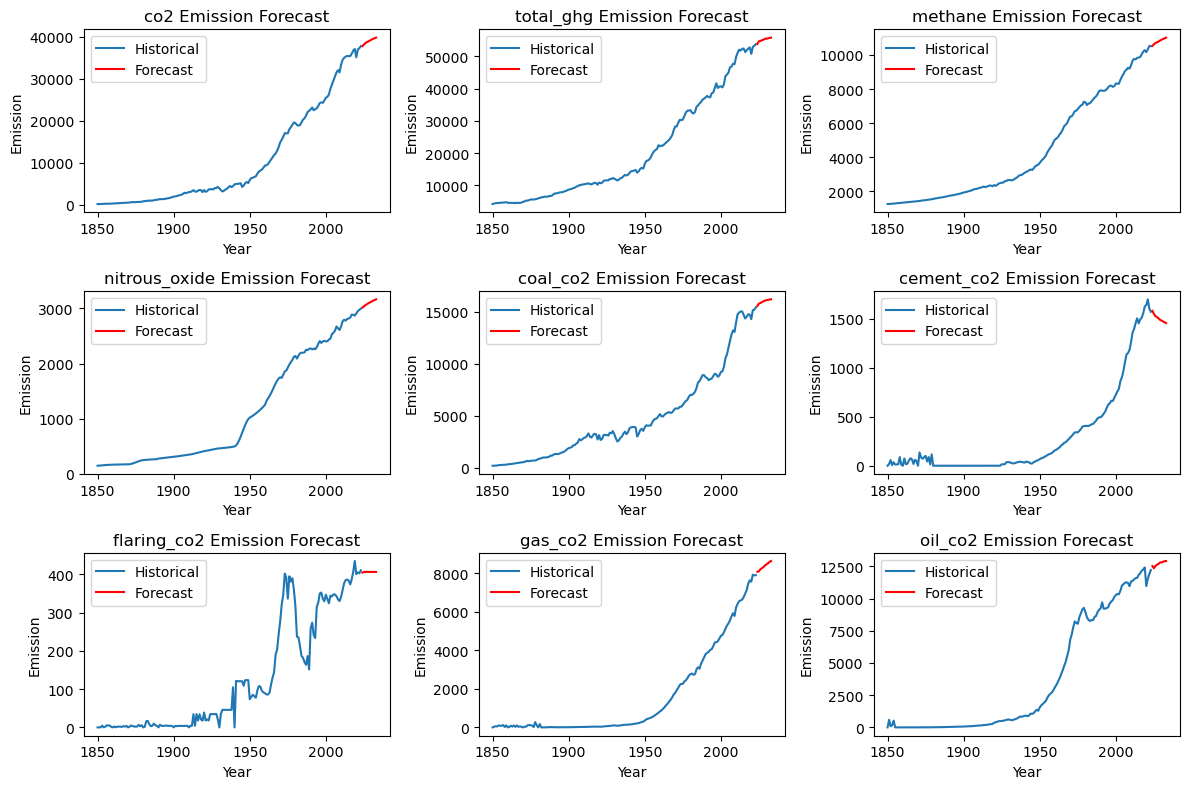

In [ ]:
# plot forecasts
plt.figure(figsize=(12, 8))
for i, emission in enumerate(emissions):
    plt.subplot(3, 3, i+1)
    plt.plot(world_data[emission], label='Historical')
    plt.plot(range(world_data.index[-1]+1, world_data.index[-1]+11), forecasts[emission], label='Forecast', color='red')
    plt.title(f'{emission} Emission Forecast')
    plt.xlabel('Year')
    plt.ylabel('Emission')
    plt.legend()
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resu

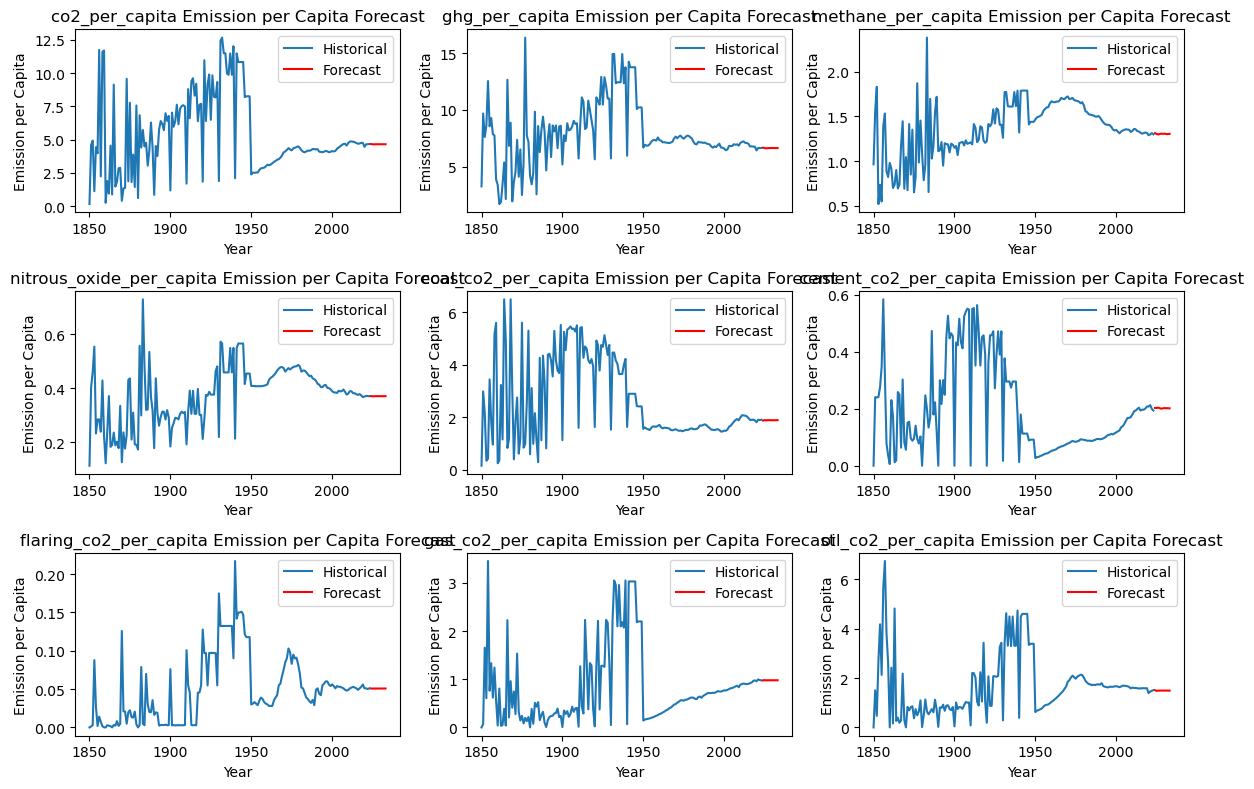

In [ ]:
emission_per_capita = ['co2_per_capita','ghg_per_capita','methane_per_capita','nitrous_oxide_per_capita' ,'coal_co2_per_capita','cement_co2_per_capita','flaring_co2_per_capita','gas_co2_per_capita','oil_co2_per_capita']
forecasts_per_capita = {}
for emission in emission_per_capita:
    model = ARIMA(world_data[emission], order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=10)
    forecasts_per_capita[emission] = forecast

# plot forecasts per capita
plt.figure(figsize=(12, 8))
for i, emission in enumerate(emission_per_capita):
    plt.subplot(3, 3, i+1)
    plt.plot(world_data[emission], label='Historical')
    plt.plot(range(world_data.index[-1]+1, world_data.index[-1]+11), forecasts_per_capita[emission], label='Forecast', color='red')
    plt.title(f'{emission} Emission per Capita Forecast')
    plt.xlabel('Year')
    plt.ylabel('Emission per Capita')
    plt.legend()
plt.tight_layout()
plt.show()

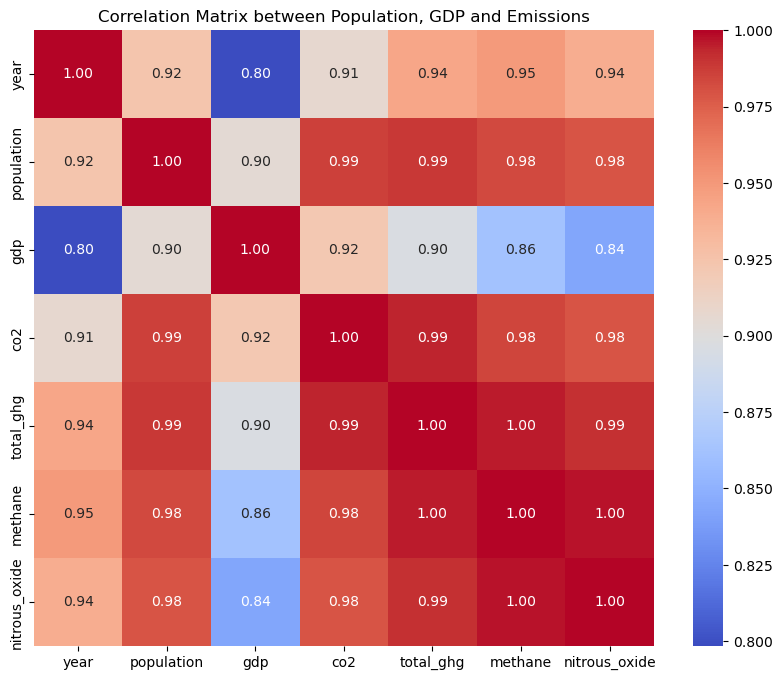

In [ ]:
# correlation between population, gdp and emissions
correlation_data = df[df['Name'] == 'World'][['year', 'population', 'gdp', 'co2', 'total_ghg', 'methane', 'nitrous_oxide']]
correlation_matrix = correlation_data.corr()
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix between Population, GDP and Emissions')
plt.show()


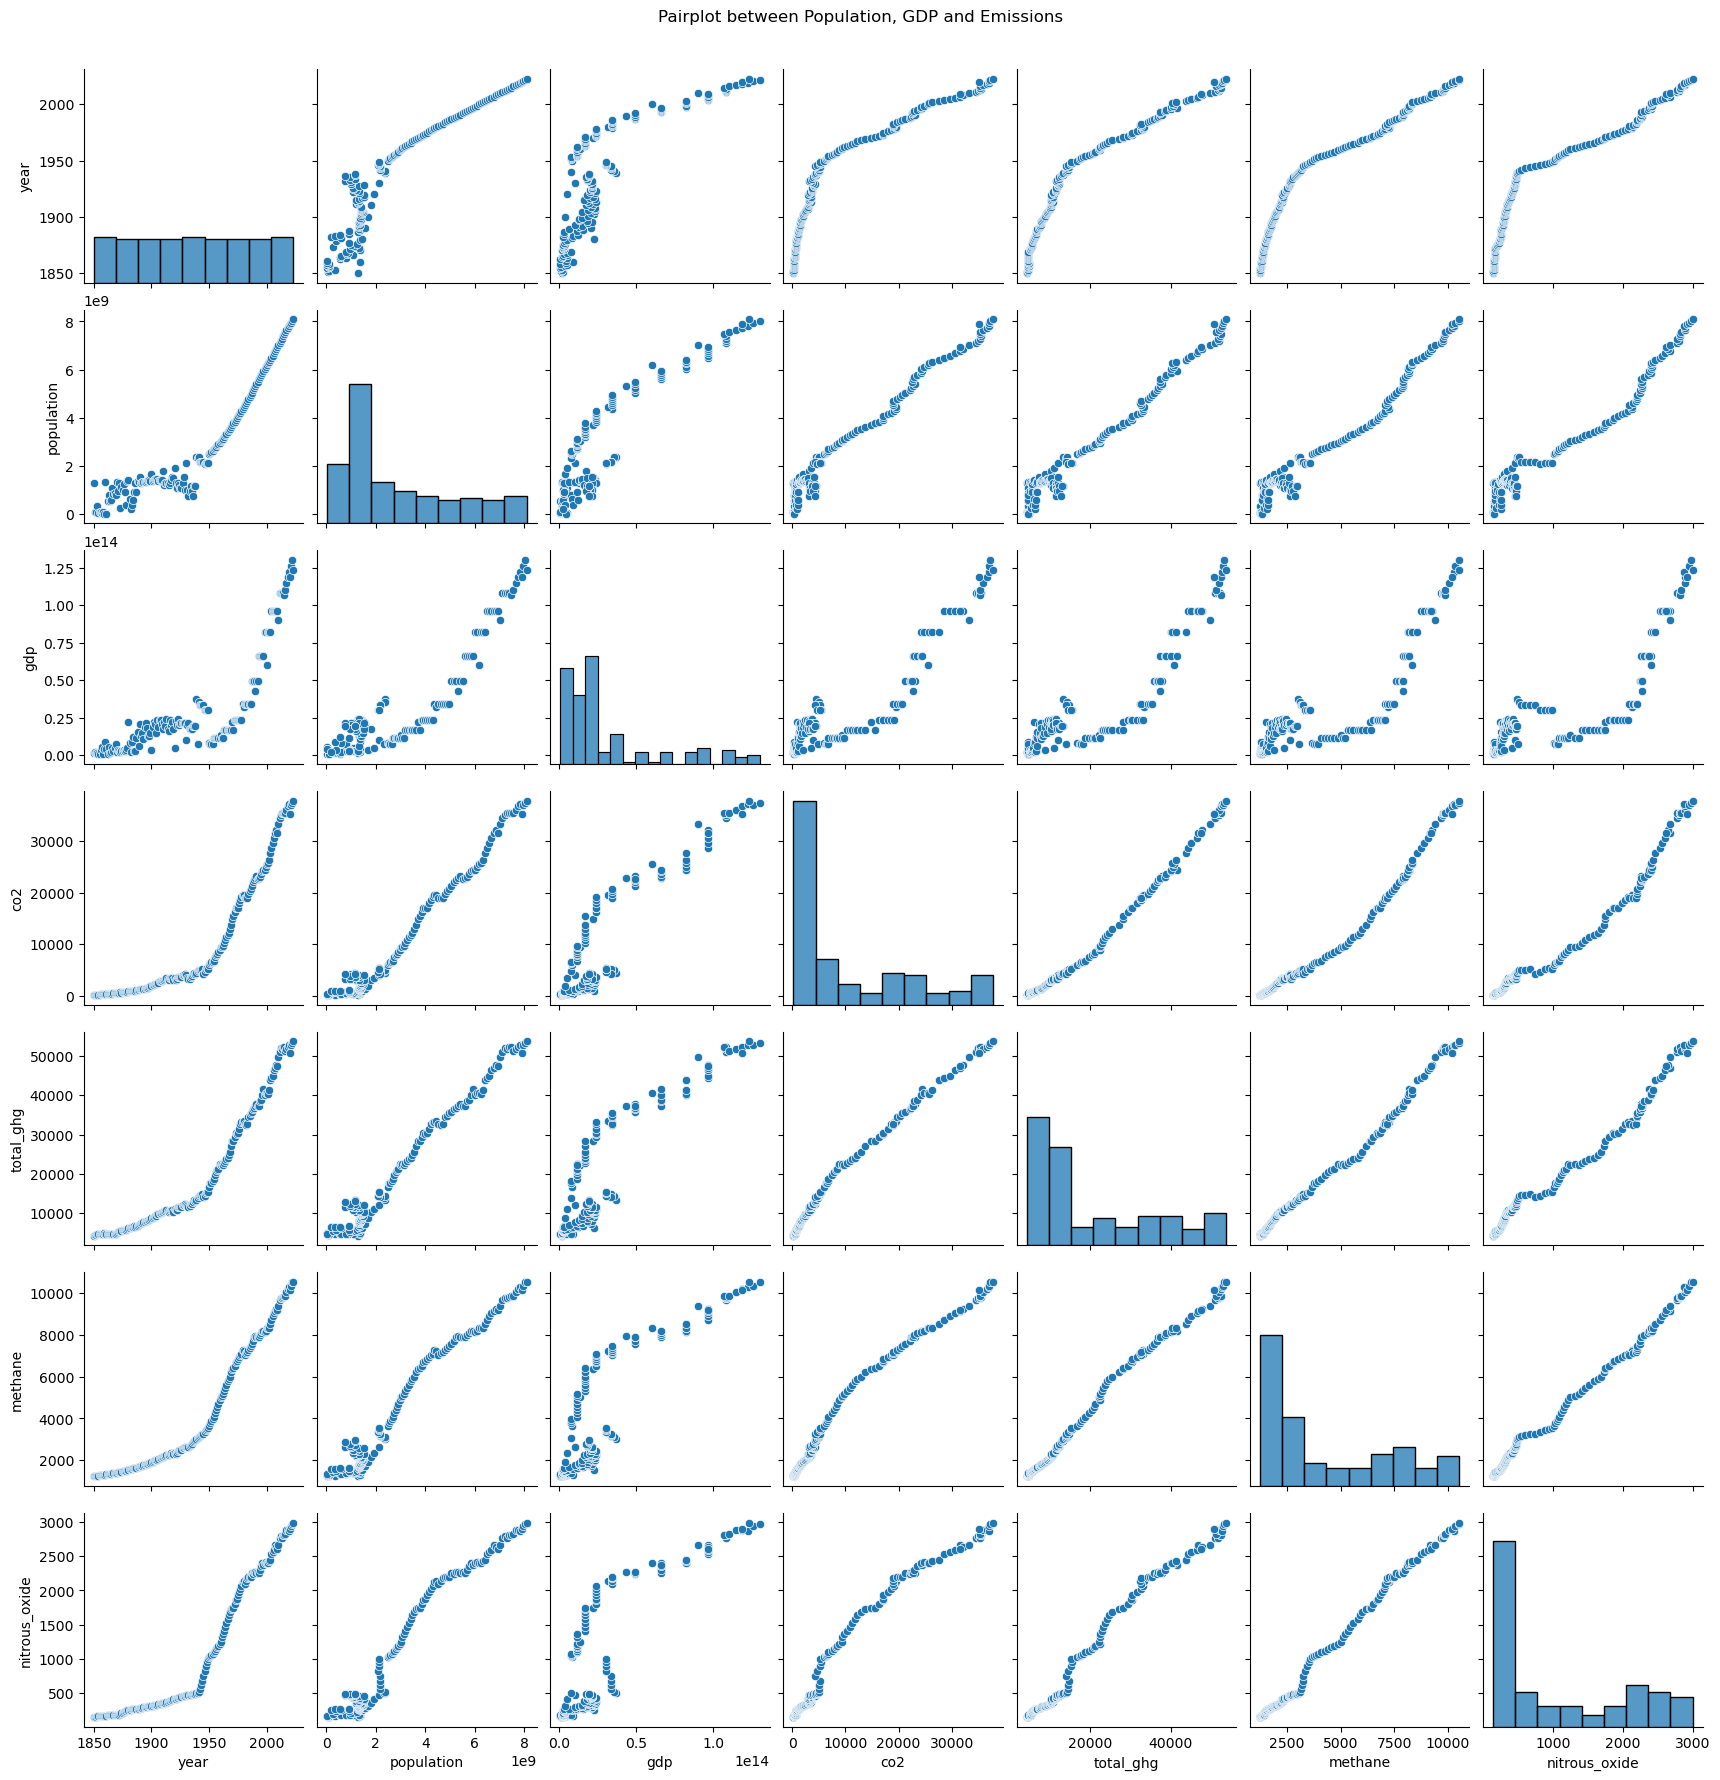

In [ ]:
# pairplot between population, gdp and emissions
sns.pairplot(correlation_data)
plt.suptitle('Pairplot between Population, GDP and Emissions', y=1.02)
plt.show()

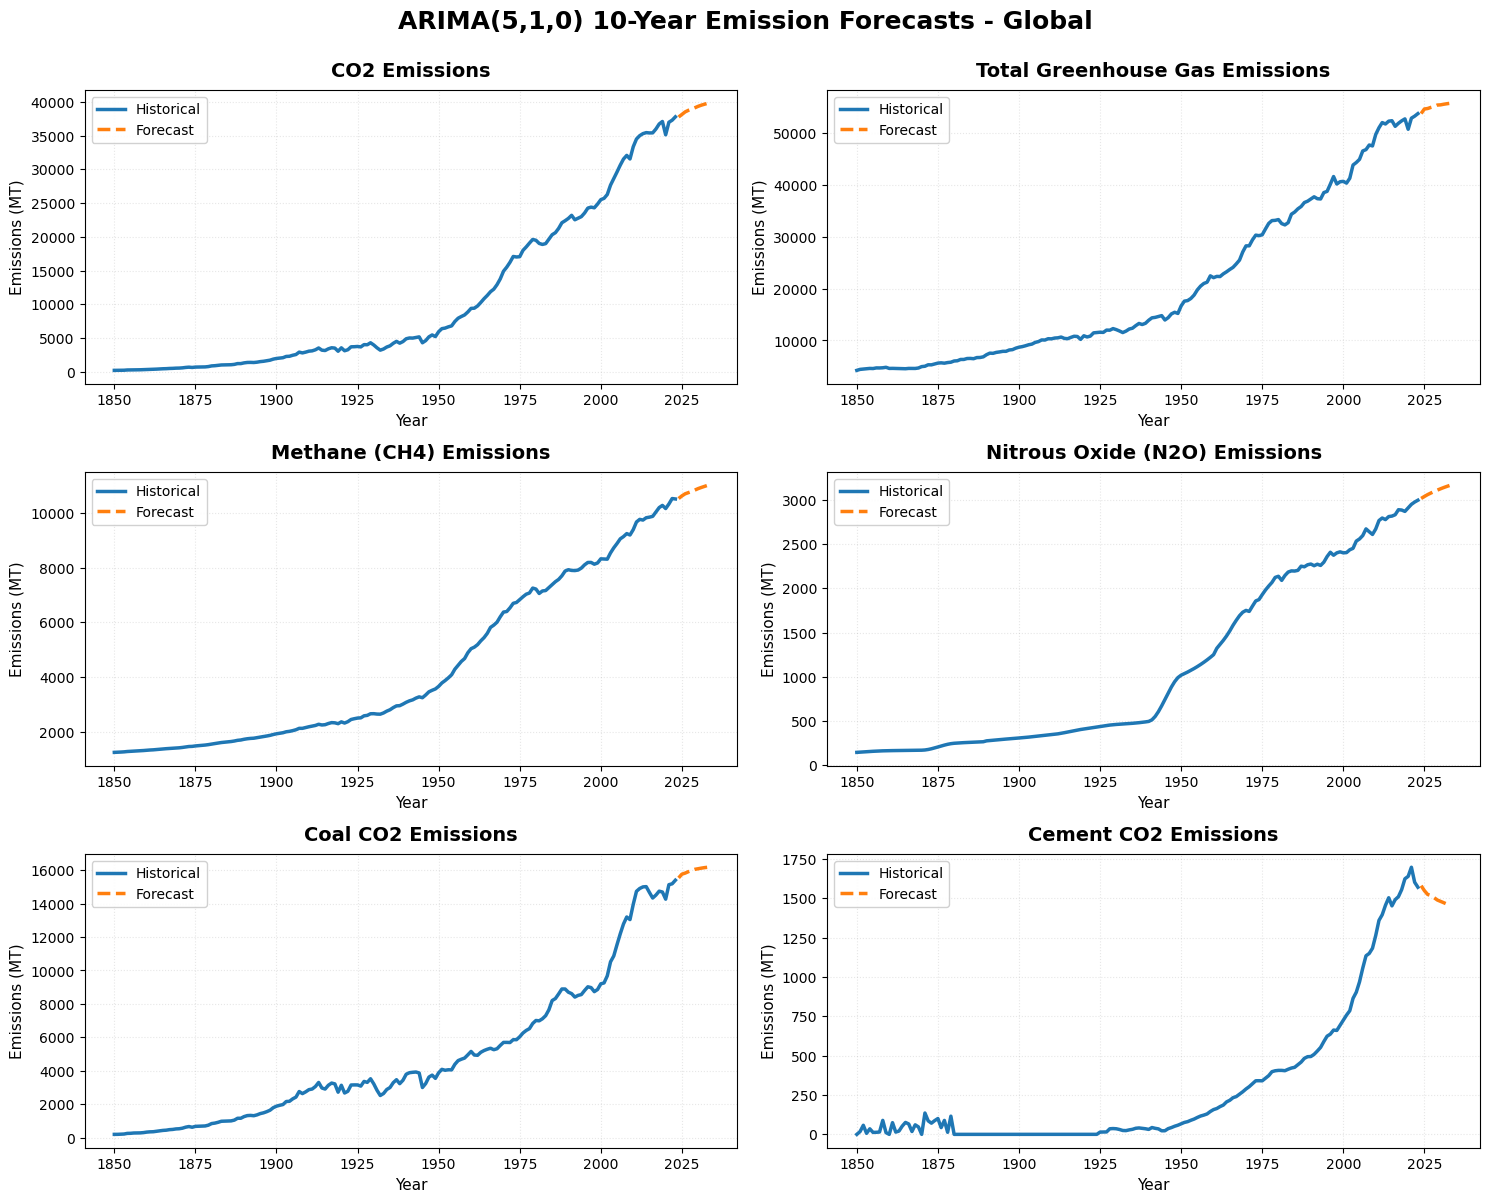


## Forecast Summary (Last Historical vs. 10-Year Ahead)

| Emission Type        |   Last Historical (2022) |   Forecast (2032) |   Change (%) |
|:---------------------|-------------------------:|------------------:|-------------:|
| CO2                  |                 37791.6  |          39807.9  |         5.34 |
| Total Greenhouse Gas |                 53816.8  |          55820.7  |         3.72 |
| Methane (CH4)        |                 10514.6  |          11016.8  |         4.78 |
| Nitrous Oxide (N2O)  |                  2996.29 |           3165.66 |         5.65 |
| Coal CO2             |                 15401.2  |          16177.1  |         5.04 |
| Cement CO2           |                  1569.35 |           1454.98 |        -7.29 |


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Read data
df = pd.read_csv('data_clean.csv')
world_data = df[df['Name'] == 'World'].set_index('year')

# Define emissions with better display names
emissions_config = {
    'co2': 'CO2',
    'total_ghg': 'Total Greenhouse Gas',
    'methane': 'Methane (CH4)',
    'nitrous_oxide': 'Nitrous Oxide (N2O)',
    'coal_co2': 'Coal CO2',
    'cement_co2': 'Cement CO2'
}

# Generate forecasts
forecasts = {}
for emission in emissions_config.keys():
    model = ARIMA(world_data[emission], order=(5, 1, 0))
    model_fit = model.fit()
    forecasts[emission] = model_fit.forecast(steps=10)

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (emission, display_name) in enumerate(emissions_config.items()):
    ax = axes[i]
    
    # Historical data
    ax.plot(world_data.index, world_data[emission], 
            label='Historical', color='#1f77b4', linewidth=2.5)
    
    # Forecast
    forecast_years = range(world_data.index[-1] + 1, world_data.index[-1] + 11)
    ax.plot(forecast_years, forecasts[emission], 
            label='Forecast', color='#ff7f0e', linewidth=2.5, linestyle='--')
    
    # Formatting
    ax.set_title(f'{display_name} Emissions', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Emissions (MT)', fontsize=11)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.tick_params(labelsize=10)

plt.suptitle('ARIMA(5,1,0) 10-Year Emission Forecasts - Global', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('arima_forecasts_6_types.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n## Forecast Summary (Last Historical vs. 10-Year Ahead)\n")
summary = pd.DataFrame({
    'Emission Type': [emissions_config[e] for e in emissions_config.keys()],
    'Last Historical (2022)': [world_data[e].iloc[-1] for e in emissions_config.keys()],
    'Forecast (2032)': [forecasts[e].iloc[-1] for e in emissions_config.keys()],
    'Change (%)': [((forecasts[e].iloc[-1] - world_data[e].iloc[-1]) / world_data[e].iloc[-1] * 100) 
                   for e in emissions_config.keys()]
})
print(summary.round(2).to_markdown(index=False))


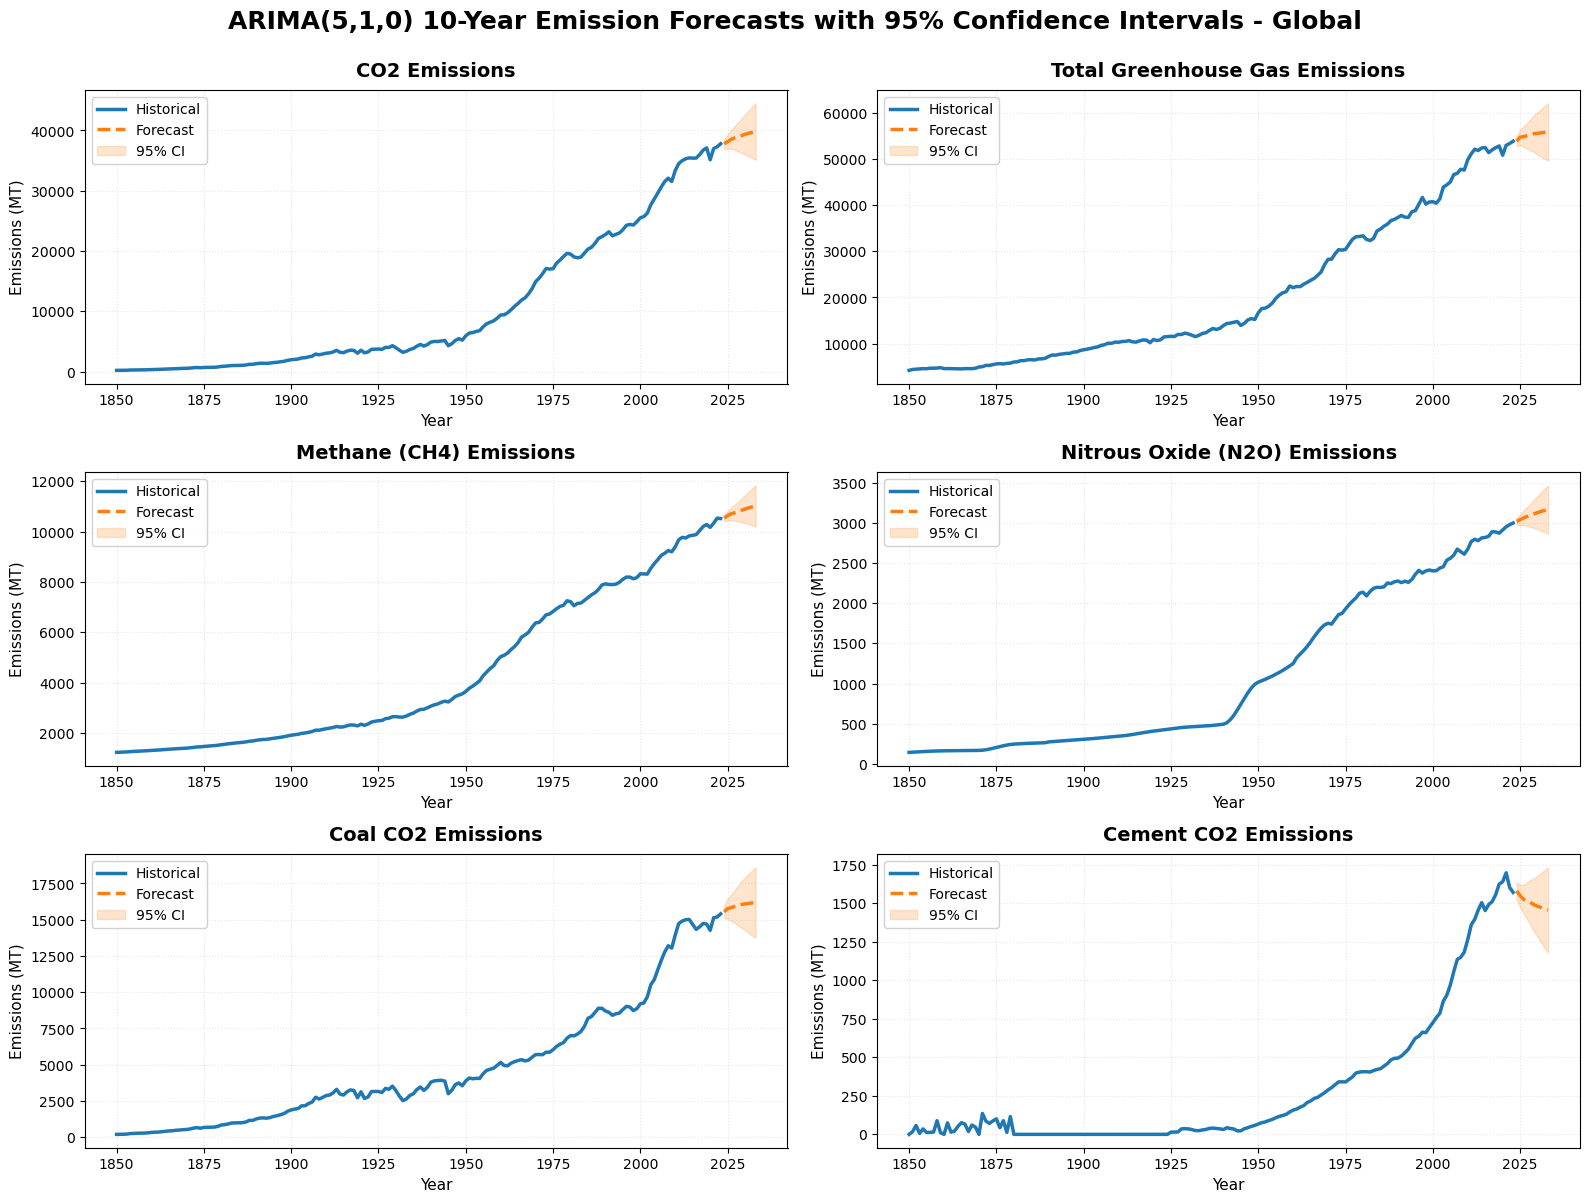


## 10-Year Emission Forecasts with 95% Confidence Intervals


### CO2

|   Year |   Forecast |   Lower 95% CI |   Upper 95% CI |
|-------:|-----------:|---------------:|---------------:|
|   2024 |    37770.2 |        36973.4 |        38567   |
|   2025 |    38142.6 |        36942.8 |        39342.5 |
|   2026 |    38522.6 |        36963.2 |        40082   |
|   2027 |    38756.2 |        36812.8 |        40699.5 |
|   2028 |    38933.7 |        36537.3 |        41330   |
|   2029 |    39136.7 |        36273.6 |        41999.7 |
|   2030 |    39349.7 |        36032.2 |        42667.2 |
|   2031 |    39522   |        35748.1 |        43296   |
|   2032 |    39667.5 |        35428.8 |        43906.2 |
|   2033 |    39807.9 |        35103.2 |        44512.5 |

### Total Greenhouse Gas

|   Year |   Forecast |   Lower 95% CI |   Upper 95% CI |
|-------:|-----------:|---------------:|---------------:|
|   2024 |    53832.3 |        52723   |        54941.7 |
|   2025 |    54708.3 |        

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Read the raw CSV file
df = pd.read_csv('data_clean.csv')

# Filter for World data only
world_data = df[df['Name'] == 'World'].set_index('year')

# Define the 6 emission types to forecast
emissions_config = {
    'co2': 'CO2',
    'total_ghg': 'Total Greenhouse Gas',
    'methane': 'Methane (CH4)',
    'nitrous_oxide': 'Nitrous Oxide (N2O)',
    'coal_co2': 'Coal CO2',
    'cement_co2': 'Cement CO2'
}

# Dictionary to store forecasts and confidence intervals
forecasts = {}
conf_intervals = {}

# Generate ARIMA forecasts with 95% CI for each emission type
for emission in emissions_config.keys():
    # Fit ARIMA(5,1,0) model
    model = ARIMA(world_data[emission], order=(5, 1, 0))
    model_fit = model.fit()
    
    # Get forecast object with confidence intervals
    forecast_obj = model_fit.get_forecast(steps=10)
    
    # Extract predicted mean and 95% confidence intervals
    forecasts[emission] = forecast_obj.predicted_mean
    conf_intervals[emission] = forecast_obj.conf_int(alpha=0.05)  # 95% CI

# Create 3x2 subplot grid for all 6 emission types
fig, axes = plt.subplots(3,2, figsize=(16, 12))
axes = axes.flatten()

forecast_years = range(world_data.index[-1] + 1, world_data.index[-1] + 11)

for i, (emission, display_name) in enumerate(emissions_config.items()):
    ax = axes[i]
    
    # Plot historical data
    ax.plot(world_data.index, world_data[emission], 
            label='Historical', color='#1f77b4', linewidth=2.5)
    
    # Plot forecast (mean prediction)
    ax.plot(forecast_years, forecasts[emission], 
            label='Forecast', color='#ff7f0e', linewidth=2.5, linestyle='--')
    
    # Plot 95% confidence interval as shaded area
    ax.fill_between(forecast_years, 
                     conf_intervals[emission].iloc[:, 0],  # Lower bound
                     conf_intervals[emission].iloc[:, 1],  # Upper bound
                     color='#ff7f0e', alpha=0.2, label='95% CI')
    
    # Formatting
    ax.set_title(f'{display_name} Emissions', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Emissions (MT)', fontsize=11)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.tick_params(labelsize=10)

plt.suptitle('ARIMA(5,1,0) 10-Year Emission Forecasts with 95% Confidence Intervals - Global', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('arima_forecasts_with_CI.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed forecast summary table with CI
print("\n## 10-Year Emission Forecasts with 95% Confidence Intervals\n")
for emission, display_name in emissions_config.items():
    print(f"\n### {display_name}\n")
    
    forecast_table = pd.DataFrame({
        'Year': forecast_years,
        'Forecast': forecasts[emission].values.round(2),
        'Lower 95% CI': conf_intervals[emission].iloc[:, 0].values.round(2),
        'Upper 95% CI': conf_intervals[emission].iloc[:, 1].values.round(2)
    })
    
    print(forecast_table.to_markdown(index=False))


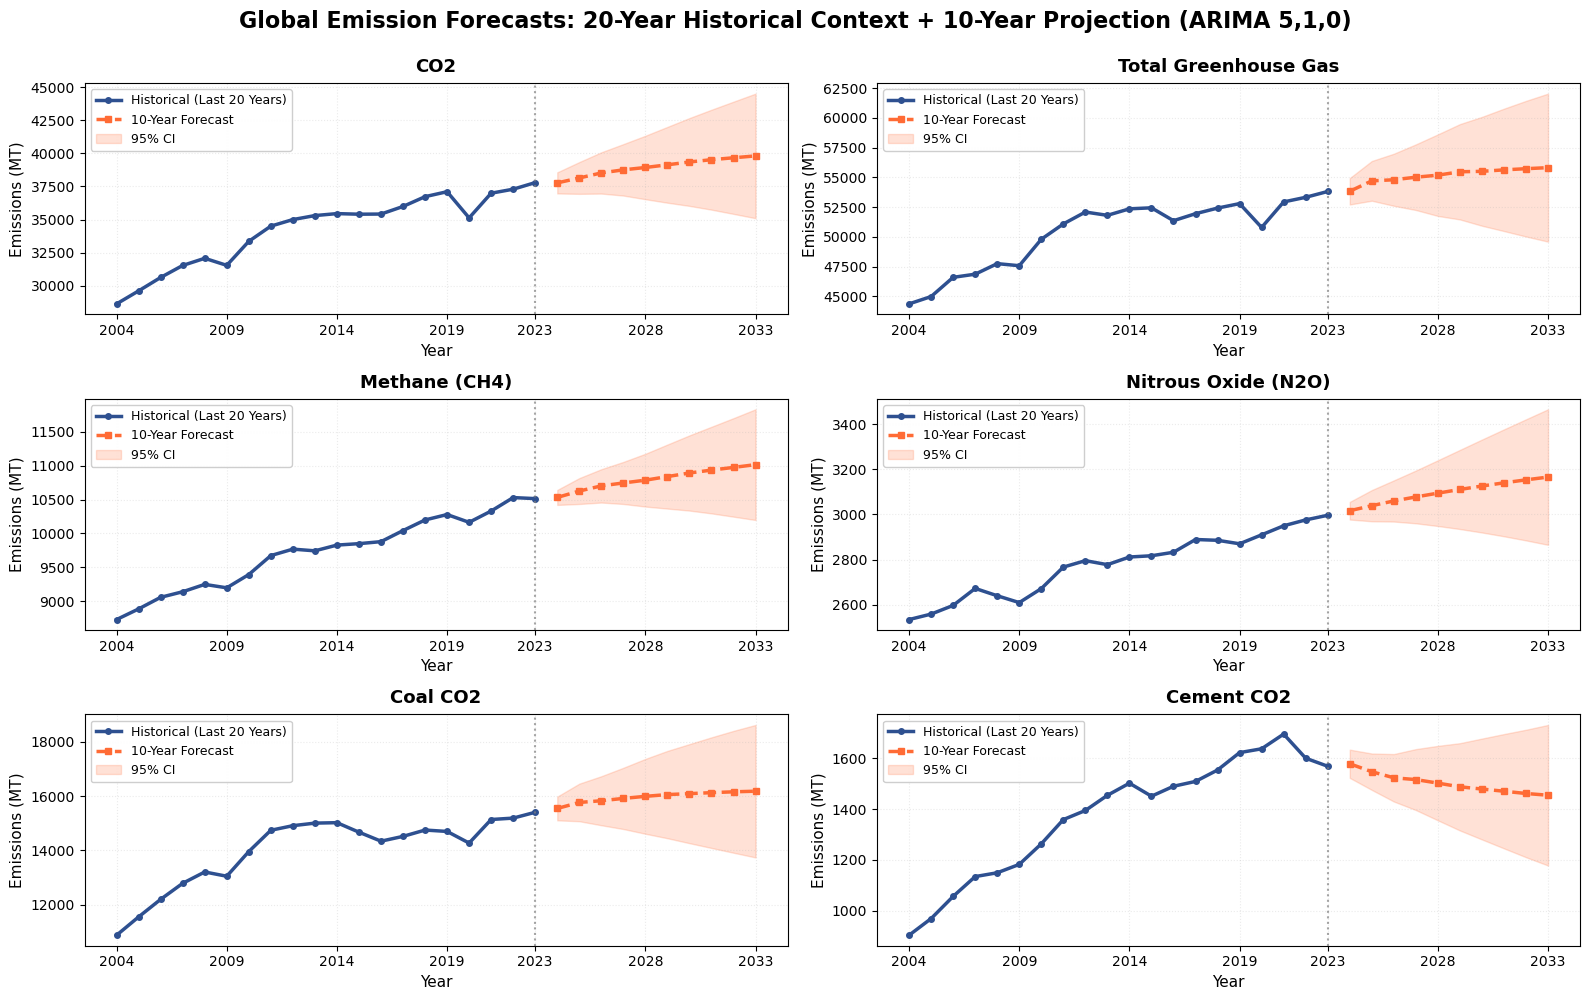


✓ Visualization saved as 'emission_forecasts_ppt_ready.png'
✓ Time range: 2004-2023 (historical) + 2024-2033 (forecast)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Read the raw CSV file
df = pd.read_csv('data_clean.csv')

# Filter for World data only
world_data = df[df['Name'] == 'World'].set_index('year')

# Get last 20 years of historical data
current_year = world_data.index[-1]
start_year = current_year - 19  # Last 20 years
world_recent = world_data[world_data.index >= start_year]

# Define the 6 emission types to forecast
emissions_config = {
    'co2': 'CO2',
    'total_ghg': 'Total Greenhouse Gas',
    'methane': 'Methane (CH4)',
    'nitrous_oxide': 'Nitrous Oxide (N2O)',
    'coal_co2': 'Coal CO2',
    'cement_co2': 'Cement CO2'
}

# Dictionary to store forecasts and confidence intervals
forecasts = {}
conf_intervals = {}

# Generate ARIMA forecasts with 95% CI for each emission type
for emission in emissions_config.keys():
    # Fit ARIMA(5,1,0) model on full historical data
    model = ARIMA(world_data[emission], order=(5, 1, 0))
    model_fit = model.fit()
    
    # Get forecast with confidence intervals
    forecast_obj = model_fit.get_forecast(steps=10)
    forecasts[emission] = forecast_obj.predicted_mean
    conf_intervals[emission] = forecast_obj.conf_int(alpha=0.05)

# Create 3x2 subplot grid - PPT optimized
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

forecast_years = range(current_year + 1, current_year + 11)

for i, (emission, display_name) in enumerate(emissions_config.items()):
    ax = axes[i]
    
    # Plot last 20 years historical data
    ax.plot(world_recent.index, world_recent[emission], 
            label='Historical (Last 20 Years)', color='#2E5090', linewidth=2.5, marker='o', markersize=4)
    
    # Plot forecast
    ax.plot(forecast_years, forecasts[emission], 
            label='10-Year Forecast', color='#FF6B35', linewidth=2.5, linestyle='--', marker='s', markersize=4)
    
    # Plot 95% confidence interval
    ax.fill_between(forecast_years, 
                     conf_intervals[emission].iloc[:, 0],
                     conf_intervals[emission].iloc[:, 1],
                     color='#FF6B35', alpha=0.2, label='95% CI')
    
    # Add vertical line at transition point
    ax.axvline(x=current_year, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_title(f'{display_name}', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Emissions (MT)', fontsize=11)
    ax.legend(loc='best', fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.tick_params(labelsize=10)
    
    # Format x-axis to show fewer years (cleaner for PPT)
    ax.set_xticks([start_year, start_year+5, start_year+10, start_year+15, current_year, current_year+5, current_year+10])

plt.suptitle('Global Emission Forecasts: 20-Year Historical Context + 10-Year Projection (ARIMA 5,1,0)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('emission_forecasts_ppt_ready.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Visualization saved as 'emission_forecasts_ppt_ready.png'")
print(f"✓ Time range: {start_year}-{current_year} (historical) + {current_year+1}-{current_year+10} (forecast)")


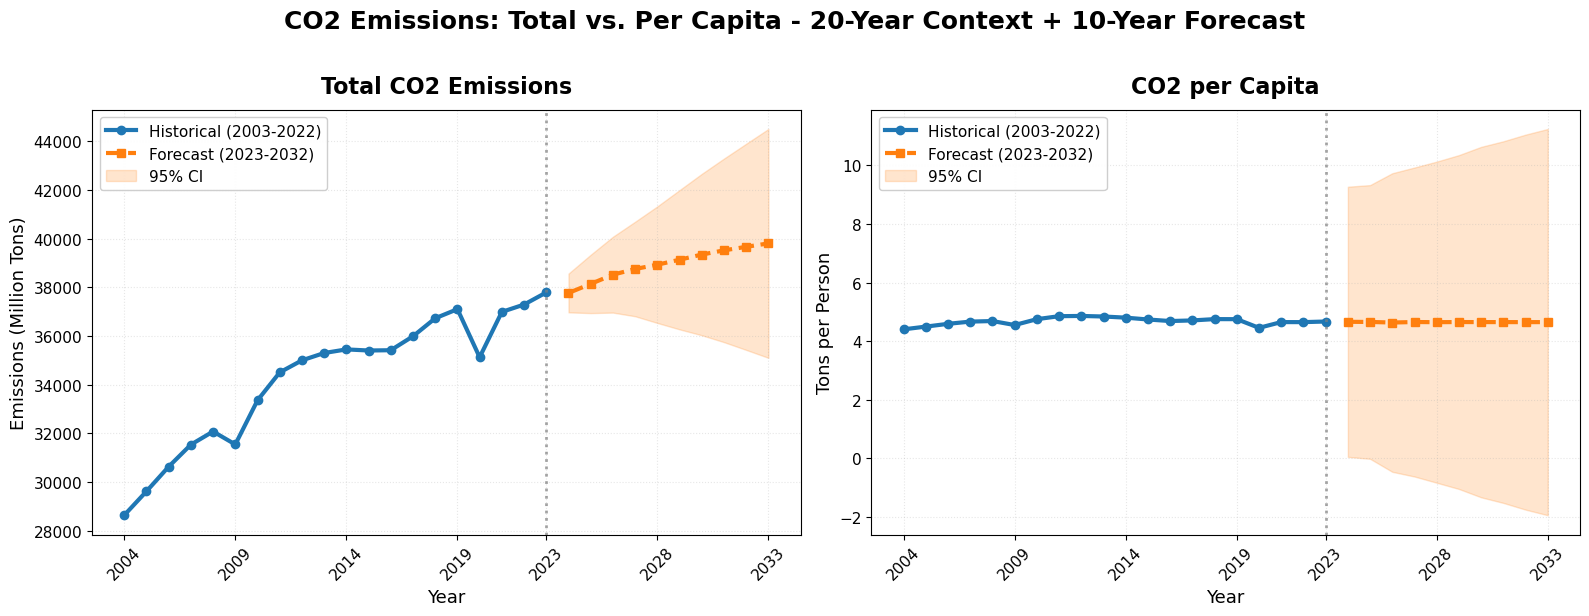


## Slide 7: CO2 Forecast Summary

| Metric              |   2023 Actual |   2033 Forecast |   Lower 95% CI |   Upper 95% CI |   Change (%) |
|:--------------------|--------------:|----------------:|---------------:|---------------:|-------------:|
| Total CO2 Emissions |      37791.6  |        39807.9  |       35103.2  |       44512.5  |          5.3 |
| CO2 per Capita      |          4.67 |            4.65 |          -1.94 |          11.24 |         -0.4 |

✓ Slide 7 visualization saved as 'slide7_co2_percapita_comparison.png'


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Read the raw CSV file
df = pd.read_csv('data_clean.csv')

# Filter for World data only
world_data = df[df['Name'] == 'World'].set_index('year')

# Get last 20 years of historical data
current_year = world_data.index[-1]
start_year = current_year - 19
world_recent = world_data[world_data.index >= start_year]

# Focus on CO2 and per-capita metrics
emissions_focus = {
    'co2': 'Total CO2 Emissions',
    'co2_per_capita': 'CO2 per Capita'
}

# Generate forecasts with 95% CI
forecasts = {}
conf_intervals = {}

for emission in emissions_focus.keys():
    model = ARIMA(world_data[emission], order=(5, 1, 0))
    model_fit = model.fit()
    forecast_obj = model_fit.get_forecast(steps=10)
    forecasts[emission] = forecast_obj.predicted_mean
    conf_intervals[emission] = forecast_obj.conf_int(alpha=0.05)

# Create side-by-side comparison for PPT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

forecast_years = range(current_year + 1, current_year + 11)

for i, (emission, display_name) in enumerate(emissions_focus.items()):
    ax = axes[i]
    
    # Historical data (last 20 years)
    ax.plot(world_recent.index, world_recent[emission], 
            label='Historical (2003-2022)', 
            color='#1f77b4', linewidth=3, marker='o', markersize=6)
    
    # Forecast
    ax.plot(forecast_years, forecasts[emission], 
            label='Forecast (2023-2032)', 
            color='#ff7f0e', linewidth=3, linestyle='--', marker='s', markersize=6)
    
    # 95% Confidence Interval
    ax.fill_between(forecast_years, 
                     conf_intervals[emission].iloc[:, 0],
                     conf_intervals[emission].iloc[:, 1],
                     color='#ff7f0e', alpha=0.2, label='95% CI')
    
    # Transition line
    ax.axvline(x=current_year, color='gray', linestyle=':', linewidth=2, alpha=0.7)
    
    # Formatting
    ax.set_title(display_name, fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('Year', fontsize=13)
    
    if emission == 'co2':
        ax.set_ylabel('Emissions (Million Tons)', fontsize=13)
    else:
        ax.set_ylabel('Tons per Person', fontsize=13)
    
    ax.legend(loc='best', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.tick_params(labelsize=11)
    
    # Format x-axis
    ax.set_xticks([start_year, start_year+5, start_year+10, start_year+15, 
                   current_year, current_year+5, current_year+10])
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('CO2 Emissions: Total vs. Per Capita - 20-Year Context + 10-Year Forecast', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide7_co2_percapita_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Generate summary table for slide notes
print("\n## Slide 7: CO2 Forecast Summary\n")

summary_data = []
for emission, display_name in emissions_focus.items():
    last_historical = world_recent[emission].iloc[-1]
    forecast_2032 = forecasts[emission].iloc[-1]
    lower_ci = conf_intervals[emission].iloc[-1, 0]
    upper_ci = conf_intervals[emission].iloc[-1, 1]
    change_pct = ((forecast_2032 - last_historical) / last_historical * 100)
    
    summary_data.append({
        'Metric': display_name,
        f'{current_year} Actual': round(last_historical, 2),
        f'{current_year+10} Forecast': round(forecast_2032, 2),
        'Lower 95% CI': round(lower_ci, 2),
        'Upper 95% CI': round(upper_ci, 2),
        'Change (%)': round(change_pct, 1)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_markdown(index=False))

print(f"\n✓ Slide 7 visualization saved as 'slide7_co2_percapita_comparison.png'")


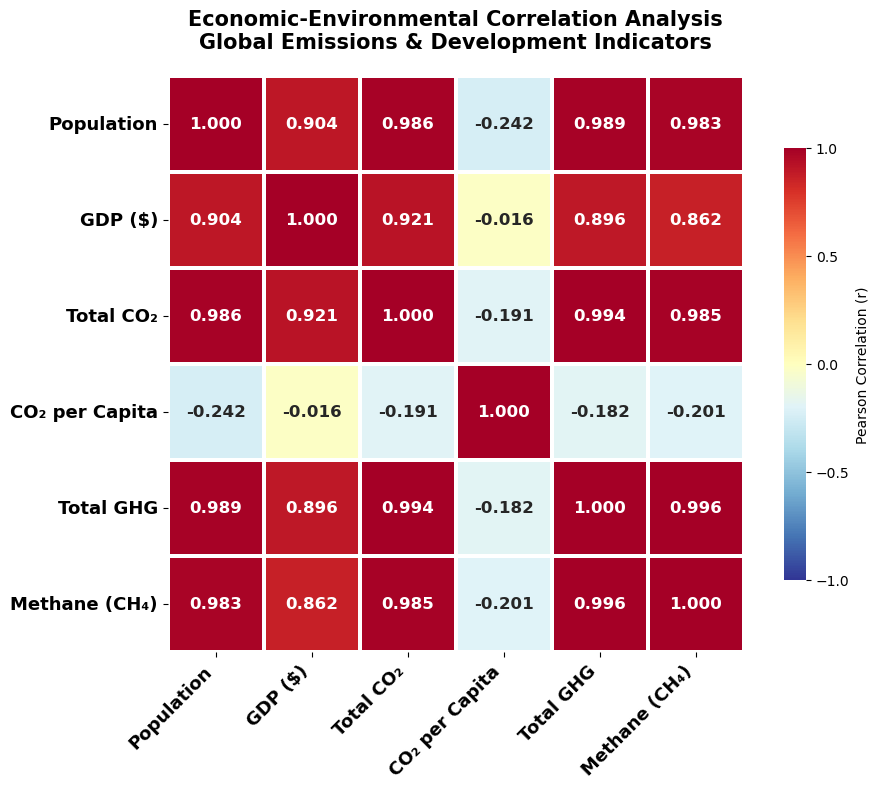

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read data
df = pd.read_csv('data_clean.csv')
world_data = df[df['Name'] == 'World'].copy()

# Focus on key economic-emission relationships
focused_vars = [
    'population',
    'gdp',
    'co2',
    'co2_per_capita',
    'total_ghg',
    'methane'
]

# Correlation matrix
corr_matrix = world_data[focused_vars].corr()

# Create publication-quality heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Mask for upper triangle (optional - shows only half)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Professional styling
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',                      # 3 decimals for precision
            cmap='RdYlBu_r',                # Red-Yellow-Blue reversed
            center=0,
            square=True,
            linewidths=1.5,
            linecolor='white',
            cbar_kws={'label': 'Pearson Correlation (r)', 
                      'shrink': 0.75,
                      'ticks': [-1, -0.5, 0, 0.5, 1]},
            vmin=-1, vmax=1,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            ax=ax)

# Clean labels
label_mapping = {
    'population': 'Population',
    'gdp': 'GDP ($)',
    'co2': 'Total CO₂',
    'co2_per_capita': 'CO₂ per Capita',
    'total_ghg': 'Total GHG',
    'methane': 'Methane (CH₄)'
}

ax.set_xticklabels([label_mapping[col] for col in corr_matrix.columns],
                    rotation=45, ha='right', fontsize=13, fontweight='semibold')
ax.set_yticklabels([label_mapping[col] for col in corr_matrix.columns],
                    rotation=0, fontsize=13, fontweight='semibold')

# Title
plt.title('Economic-Environmental Correlation Analysis\nGlobal Emissions & Development Indicators',
          fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('slide8_correlation_focused.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


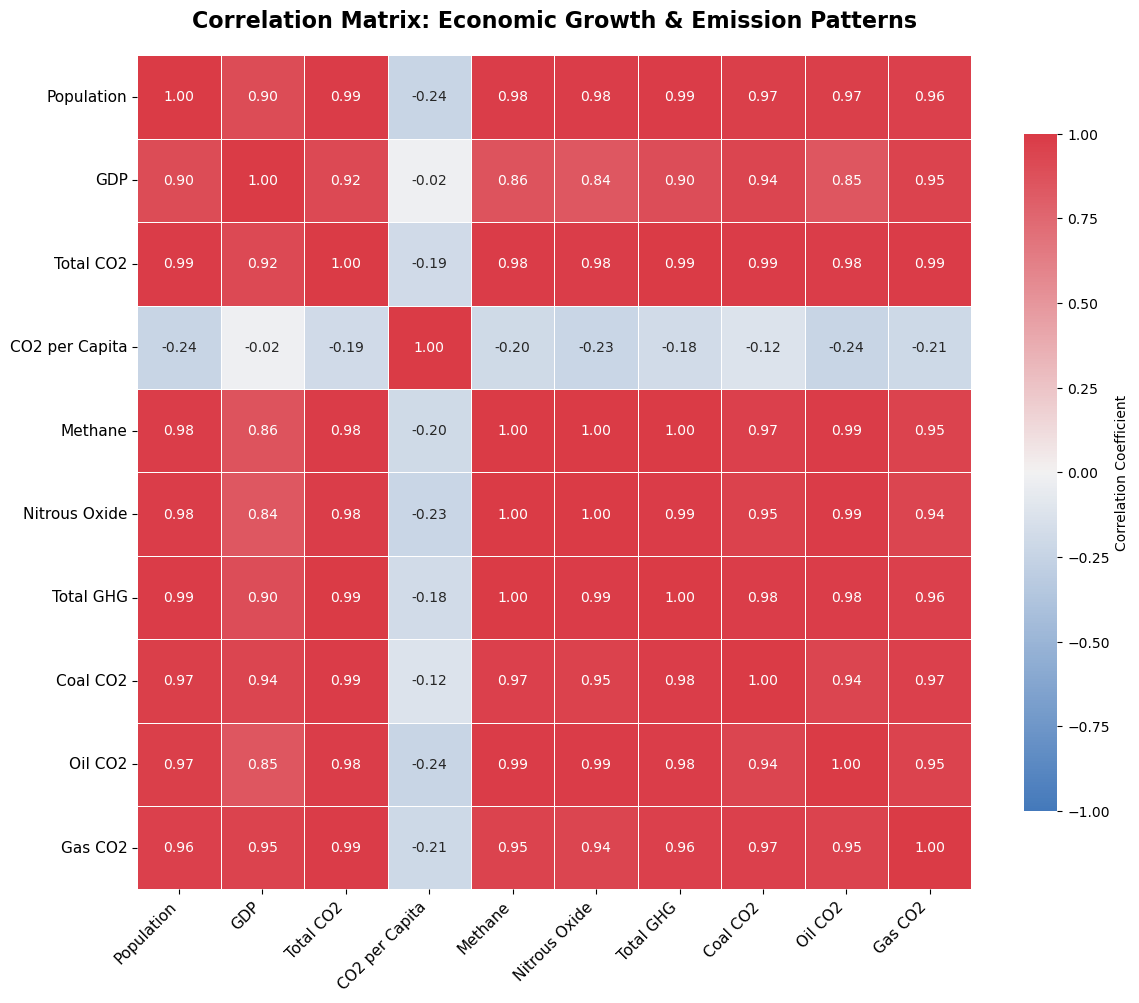


## Key Correlation Insights

| Variable 1    | Variable 2    |   Correlation | Strength    |
|:--------------|:--------------|--------------:|:------------|
| Methane       | Nitrous Oxide |         0.997 | Very Strong |
| Methane       | Total GHG     |         0.996 | Very Strong |
| Total CO2     | Total GHG     |         0.994 | Very Strong |
| Nitrous Oxide | Total GHG     |         0.991 | Very Strong |
| Nitrous Oxide | Oil CO2       |         0.989 | Very Strong |
| Population    | Total GHG     |         0.989 | Very Strong |
| Methane       | Oil CO2       |         0.986 | Very Strong |
| Population    | Total CO2     |         0.986 | Very Strong |
| Total CO2     | Methane       |         0.985 | Very Strong |
| Total CO2     | Gas CO2       |         0.985 | Very Strong |
| Total CO2     | Coal CO2      |         0.985 | Very Strong |
| Population    | Methane       |         0.983 | Very Strong |
| Total GHG     | Coal CO2      |         0.983 | Very Strong |
| Total CO

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the data
df = pd.read_csv('data_clean.csv')

# Filter for World data only
world_data = df[df['Name'] == 'World'].copy()

# Select key economic and emission variables for correlation analysis
key_vars = [
    'population',
    'gdp',
    'co2',
    'co2_per_capita',
    'methane',
    'nitrous_oxide',
    'total_ghg',
    'coal_co2',
    'oil_co2',
    'gas_co2'
]

# Create correlation matrix
corr_matrix = world_data[key_vars].corr()

# Create professional heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Custom color palette - professional blue-red diverging
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Create heatmap with annotations
sns.heatmap(corr_matrix, 
            annot=True,                    # Show correlation values
            fmt='.2f',                      # 2 decimal places
            cmap=cmap,                      # Color scheme
            center=0,                       # Center colormap at 0
            square=True,                    # Square cells
            linewidths=0.5,                 # Grid lines
            linecolor='white',              # White grid
            cbar_kws={'label': 'Correlation Coefficient',
                      'shrink': 0.8},       # Colorbar settings
            vmin=-1, vmax=1,                # Scale from -1 to 1
            ax=ax)

# Better variable labels
label_mapping = {
    'population': 'Population',
    'gdp': 'GDP',
    'co2': 'Total CO2',
    'co2_per_capita': 'CO2 per Capita',
    'methane': 'Methane',
    'nitrous_oxide': 'Nitrous Oxide',
    'total_ghg': 'Total GHG',
    'coal_co2': 'Coal CO2',
    'oil_co2': 'Oil CO2',
    'gas_co2': 'Gas CO2'
}

# Apply labels
ax.set_xticklabels([label_mapping[col] for col in corr_matrix.columns], 
                    rotation=45, ha='right', fontsize=11)
ax.set_yticklabels([label_mapping[col] for col in corr_matrix.columns], 
                    rotation=0, fontsize=11)

# Title and formatting
plt.title('Correlation Matrix: Economic Growth & Emission Patterns', 
          fontsize=16, fontweight='bold', pad=20)

# Adjust layout
plt.tight_layout()
plt.savefig('slide8_correlation_heatmap_professional.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Generate key insights table
print("\n## Key Correlation Insights\n")

# Find strongest correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.85:  # Strong correlations
            high_corr.append({
                'Variable 1': label_mapping[var1],
                'Variable 2': label_mapping[var2],
                'Correlation': round(corr_value, 3),
                'Strength': 'Very Strong' if abs(corr_value) > 0.95 else 'Strong'
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
print(high_corr_df.to_markdown(index=False))

print(f"\n✓ Professional heatmap saved as 'slide8_correlation_heatmap_professional.png'")


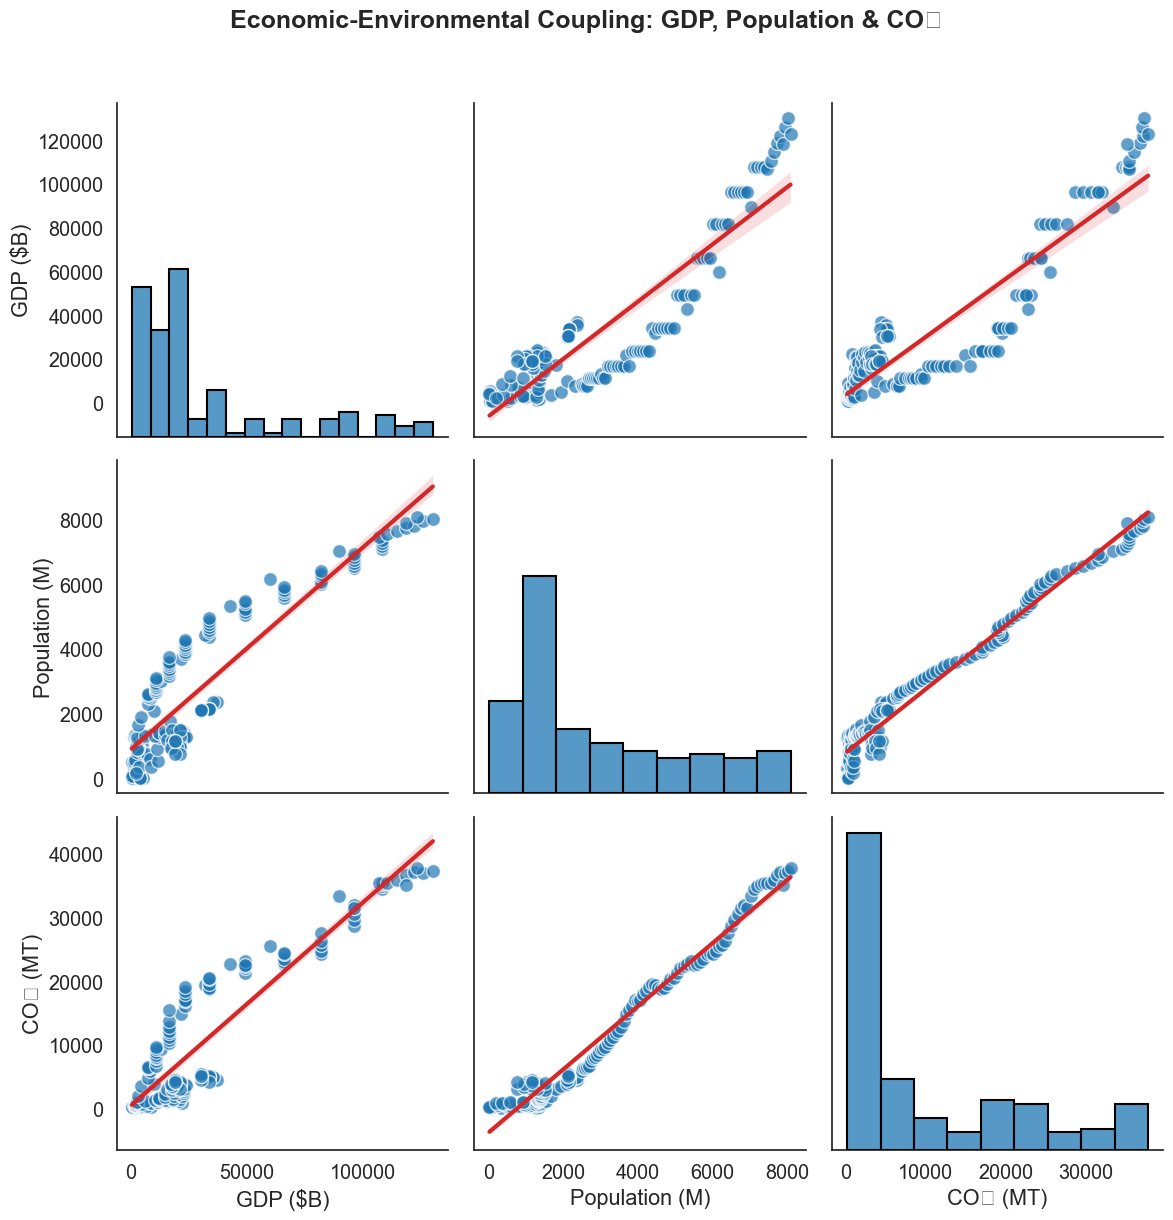

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Minimal professional style
sns.set_style('white')
sns.set_context('notebook', font_scale=1.3)

# Read data
df = pd.read_csv('data_clean.csv')
world_data = df[df['Name'] == 'World'].copy()

# Focus on core relationships: GDP, Population, CO2
core_vars = ['gdp', 'population', 'co2']
plot_data = world_data[core_vars].copy()

# Readable labels and scaling
plot_data['GDP ($B)'] = plot_data['gdp'] / 1_000_000_000
plot_data['Population (M)'] = plot_data['population'] / 1_000_000
plot_data['CO₂ (MT)'] = plot_data['co2']

# Keep only scaled columns (drop raw ones so pairplot only sees these)
final_data = plot_data[['GDP ($B)', 'Population (M)', 'CO₂ (MT)']].copy()

# Create clean pairplot
# Create clean pairplot
g = sns.pairplot(
    final_data,
    kind='reg',
    diag_kind='hist',
    plot_kws={
        # These go to seaborn.regplot
        'scatter_kws': {
            'alpha': 0.7,
            's': 100,
            'color': '#1f77b4',
            'edgecolor': 'white',
            # REMOVE linewidth to avoid linewidth/linewidths alias clash
            # 'linewidth': 1,
        },
        'line_kws': {
            'color': '#d62728',
            'linewidth': 3
        }
    },
    diag_kws={
        'color': '#1f77b4',
        'edgecolor': 'black',
        'linewidth': 1.5
    },
    height=4,
    aspect=1
)


# Remove top and right spines for cleaner look
# (Some entries in g.axes can be None depending on Seaborn version)
for ax_row in g.axes:
    for ax in ax_row:
        if ax is not None:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

# Title
g.fig.suptitle(
    'Economic-Environmental Coupling: GDP, Population & CO₂',
    fontsize=18,
    fontweight='bold',
    y=1.02  # slightly higher so it doesn't overlap
)

plt.tight_layout()
plt.savefig(
    'slide9_pairplot_minimal.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

